In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from pycbc.filter import sigma
from pycbc.noise import noise_from_psd
from pycbc.psd import interpolate
from pycbc.types import FrequencySeries
from pycbc.waveform import get_td_waveform

/HDD/swein/ggwd_env/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/HDD/swein/ggwd_env/lib/python3.12/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [7]:
sampling_rate = 2048
delta_t = 1/sampling_rate
f_lower = 4
waveform = get_td_waveform(approximant="SEOBNRv4", mass1=80, mass2=50, delta_t=delta_t, f_lower=f_lower)[0]
sample_length = len(waveform)*delta_t
td_length = sample_length*sampling_rate
delta_f = 1/sample_length
psd = FrequencySeries(np.ones(int(sampling_rate/2/delta_f+1)), delta_f=delta_f)
snr = sigma(htilde=waveform, psd=psd, low_frequency_cutoff=f_lower)
noise = noise_from_psd(int(td_length), delta_t=delta_t, psd=psd)
noise.start_time = waveform.start_time

In [5]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

matplotlib.rc("font", size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc("axes", titlesize=MEDIUM_SIZE)     # fontsize of the axes title
matplotlib.rc("axes", labelsize=SMALL_SIZE)    # fontsize of the x and y labels
matplotlib.rc("xtick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("ytick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc("legend", fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc("figure", titlesize=MEDIUM_SIZE)  # fontsize of the figure title

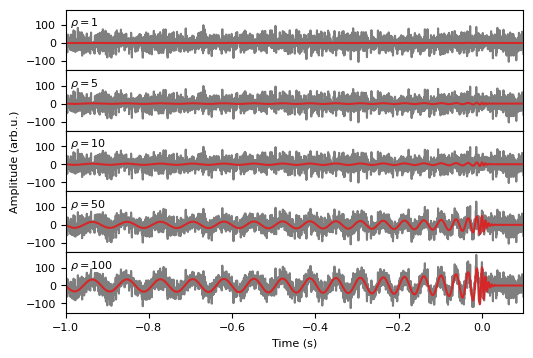

In [8]:
injection_snr = [1, 5, 10, 50, 100]
n = len(injection_snr)
fig, axs = plt.subplots(nrows=n, figsize=(15/2.54, 2*n/2.54), sharex=True, sharey=True)
for i, ax in enumerate(axs):
    scale_factor = injection_snr[i]/snr
    inject = noise.inject(scale_factor*waveform)
    ax.plot(inject.sample_times, inject, c="tab:grey")
    ax.plot(waveform.sample_times, scale_factor*waveform, c="tab:red")
    ax.text(x=-0.99,y=0.99*np.max(np.abs(np.array(noise))), s=rf"$\rho=${int(injection_snr[i])}", va="top")
axs[0].set_xlim(-1, 0.1)
axs[n//2].set_ylabel("Amplitude (arb.u.)")
axs[-1].set_xlabel("Time (s)")
fig.subplots_adjust(hspace=0)
fig.savefig("snr.png", dpi=300, bbox_inches="tight")